# Multi-Class Classification of Gravitational Lensing Images

**Task**: Classify strong gravitational lensing images into three categories:
1. **No Substructure** — lensing images with no substructure
2. **Subhalo (Sphere)** — images with subhalo substructure
3. **Vortex** — images with vortex substructure

**Approach**: Transfer learning with ResNet-18 (modified for single-channel input), trained with data augmentation, and evaluated using ROC curves and AUC scores.

**Framework**: PyTorch

## 1. Setup & Imports

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from sklearn.metrics import (
    roc_curve, auc, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cpu


## 2. Dataset Exploration

Let's first examine the dataset structure and visualize some sample images from each class.

In [3]:
# Dataset paths
DATA_DIR = os.path.join(os.path.dirname(os.getcwd()), 'src', 'dataset')
# If running from the src/ directory:
if not os.path.exists(DATA_DIR):
    DATA_DIR = os.path.join(os.getcwd(), 'dataset')

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
VAL_DIR = os.path.join(DATA_DIR, 'val')

CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_LABELS = {
    'no': 'No Substructure',
    'sphere': 'Subhalo (Sphere)',
    'vort': 'Vortex'
}

# Count images per class
print('=== Dataset Statistics ===')
for split_name, split_dir in [('Train', TRAIN_DIR), ('Val', VAL_DIR)]:
    print(f'\n{split_name} set:')
    total = 0
    for cls in CLASS_NAMES:
        cls_dir = os.path.join(split_dir, cls)
        count = len([f for f in os.listdir(cls_dir) if f.endswith('.npy')])
        print(f'  {CLASS_LABELS[cls]:25s}: {count:,} images')
        total += count
    print(f'  {"Total":25s}: {total:,} images')

=== Dataset Statistics ===

Train set:
  No Substructure          : 10,000 images
  Subhalo (Sphere)         : 10,000 images
  Vortex                   : 10,000 images
  Total                    : 30,000 images

Val set:
  No Substructure          : 2,500 images
  Subhalo (Sphere)         : 2,500 images
  Vortex                   : 2,500 images
  Total                    : 7,500 images


TypeError: Invalid shape (1, 150, 150) for image data

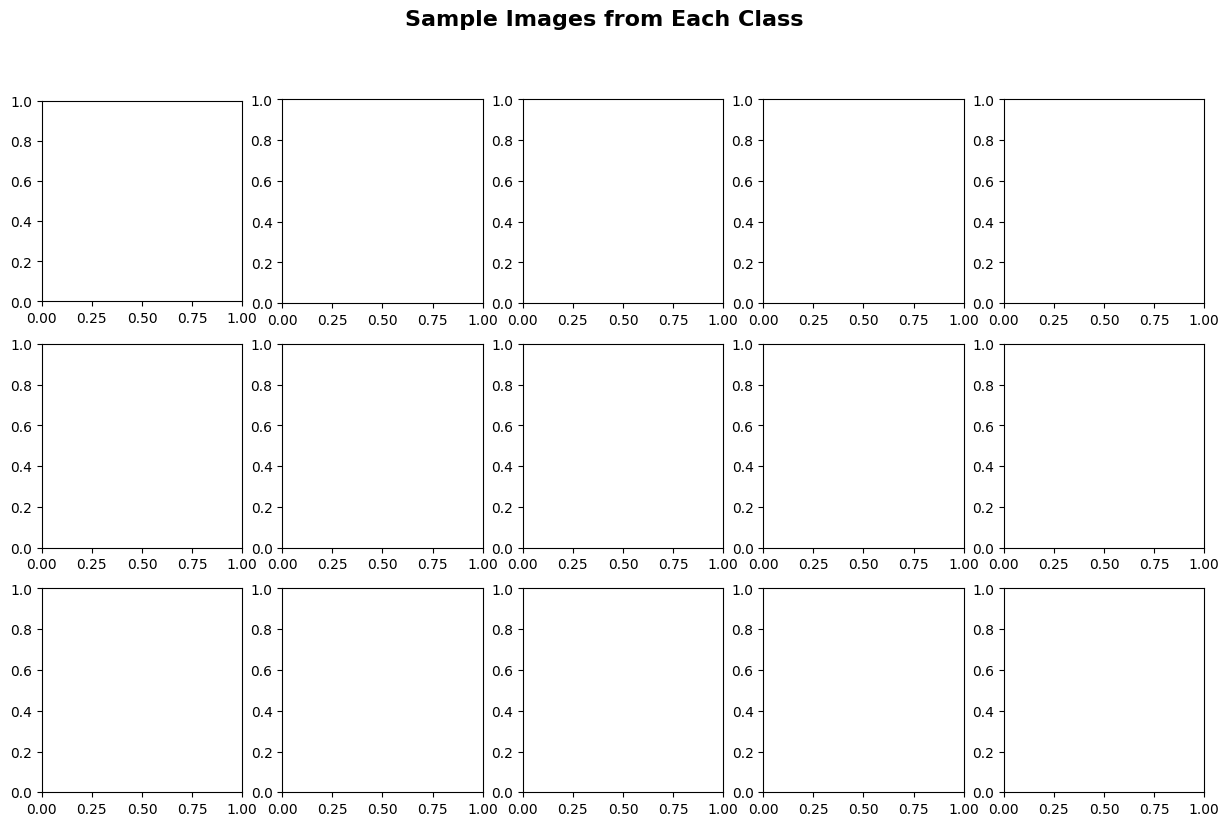

In [4]:
# Visualize sample images from each class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = sorted([f for f in os.listdir(cls_dir) if f.endswith('.npy')])[:5]
    for col, fname in enumerate(files):
        img = np.load(os.path.join(cls_dir, fname))
        axes[row, col].imshow(img, cmap='inferno')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_ylabel(CLASS_LABELS[cls], fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Check image properties
sample = np.load(os.path.join(TRAIN_DIR, 'no', '1.npy'))
print(f'\nImage shape: {sample.shape}')
print(f'Image dtype: {sample.dtype}')
print(f'Value range: [{sample.min():.4f}, {sample.max():.4f}]')

## 3. Dataset & DataLoader

Custom PyTorch `Dataset` class for loading `.npy` files with optional data augmentation.

In [ ]:
class LensingDataset(Dataset):
    """PyTorch Dataset for gravitational lensing .npy images."""

    def __init__(self, root_dir, class_names, transform=None):
        """
        Args:
            root_dir (str): Path to train/ or val/ directory.
            class_names (list): List of class folder names.
            transform (callable, optional): Transforms to apply.
        """
        self.transform = transform
        self.samples = []  # list of (file_path, label)

        for label_idx, cls_name in enumerate(class_names):
            cls_dir = os.path.join(root_dir, cls_name)
            for fname in os.listdir(cls_dir):
                if fname.endswith('.npy'):
                    self.samples.append((os.path.join(cls_dir, fname), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label = self.samples[idx]
        image = np.load(file_path).astype(np.float32)

        # Handle different image shapes
        if image.ndim == 2:
            image = image[np.newaxis, :, :]  # Add channel dim: (1, H, W)
        elif image.ndim == 3 and image.shape[2] in [1, 3]:
            image = np.transpose(image, (2, 0, 1))  # (H, W, C) -> (C, H, W)

        image = torch.from_numpy(image)

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
# Data augmentation for training
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
])

# No augmentation for validation
val_transform = None

# Create datasets
train_dataset = LensingDataset(TRAIN_DIR, CLASS_NAMES, transform=train_transform)
val_dataset = LensingDataset(VAL_DIR, CLASS_NAMES, transform=val_transform)

print(f'Training samples:   {len(train_dataset):,}')
print(f'Validation samples: {len(val_dataset):,}')

# DataLoaders
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=True
)

# Verify a batch
images, labels = next(iter(train_loader))
print(f'\nBatch shape: {images.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Unique labels: {torch.unique(labels).tolist()}')

## 4. Model Architecture

**Strategy**: Use ResNet-18 pretrained on ImageNet with two key modifications:
1. **Input layer**: Replace the first convolutional layer to accept 1-channel (grayscale) input instead of 3-channel RGB. We initialize the new conv layer by averaging the pretrained 3-channel weights.
2. **Output layer**: Replace the final fully connected layer with a 3-class output.

Transfer learning is highly effective here because the intermediate feature representations (edges, textures, patterns) learned on ImageNet generalize well to scientific imaging tasks.

In [ ]:
class LensingClassifier(nn.Module):
    """ResNet-18 based classifier for single-channel lensing images."""

    def __init__(self, num_classes=3, pretrained=True):
        super(LensingClassifier, self).__init__()

        # Load pretrained ResNet-18
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet18(weights=weights)

        # Modify first conv layer: 3-channel -> 1-channel
        original_conv = self.backbone.conv1
        self.backbone.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        # Initialize with mean of pretrained RGB weights
        if pretrained:
            with torch.no_grad():
                self.backbone.conv1.weight = nn.Parameter(
                    original_conv.weight.mean(dim=1, keepdim=True)
                )

        # Modify final FC layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# Initialize model
model = LensingClassifier(num_classes=3, pretrained=True).to(device)

# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

## 5. Training

**Training configuration:**
- **Loss**: Cross-Entropy (standard for multi-class classification)
- **Optimizer**: AdamW with weight decay regularization
- **Scheduler**: Cosine Annealing LR for smooth learning rate decay
- **Early stopping**: Patience of 5 epochs based on validation loss

In [ ]:
# Hyperparameters
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5

# Loss, optimizer, and scheduler
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch and return average loss and accuracy."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


@torch.no_grad()
def validate(model, loader, criterion, device):
    """Validate and return average loss and accuracy."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader, desc='Validation', leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

In [ ]:
# Create checkpoint directory
os.makedirs('checkpoints', exist_ok=True)

# Training loop with early stopping
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')
patience_counter = 0

print('=' * 70)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>10} | {"Val Loss":>10} | {"Val Acc":>10} | {"LR":>10}')
print('=' * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    scheduler.step()

    # Record history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    current_lr = optimizer.param_groups[0]['lr']
    print(f'{epoch:6d} | {train_loss:10.4f} | {train_acc:9.2f}% | {val_loss:10.4f} | {val_acc:9.2f}% | {current_lr:10.6f}')

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
        }, 'checkpoints/best_model.pth')
        print(f'         >>> Best model saved (val_loss: {val_loss:.4f})')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping triggered after {epoch} epochs.')
            break

print('\nTraining complete!')

## 6. Training Curves

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history['train_loss']) + 1)

# Loss curve
ax1.plot(epochs_range, history['train_loss'], 'b-o', markersize=4, label='Train Loss')
ax1.plot(epochs_range, history['val_loss'], 'r-o', markersize=4, label='Val Loss')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy curve
ax2.plot(epochs_range, history['train_acc'], 'b-o', markersize=4, label='Train Acc')
ax2.plot(epochs_range, history['val_acc'], 'r-o', markersize=4, label='Val Acc')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/training_curves.png')

## 7. Evaluation — ROC Curves & AUC Scores

Load the best model checkpoint and compute ROC/AUC metrics on the validation set.

In [ ]:
# Load best model
checkpoint = torch.load('checkpoints/best_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"(val_loss: {checkpoint['val_loss']:.4f}, val_acc: {checkpoint['val_acc']:.2f}%)")

# Collect predictions
model.eval()
all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_labels.append(labels.numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(outputs.argmax(dim=1).cpu().numpy())

all_labels = np.concatenate(all_labels)
all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)

print(f'\nTotal validation samples: {len(all_labels)}')

In [ ]:
os.makedirs('results', exist_ok=True)

# Compute ROC curve and AUC for each class (One-vs-Rest)
n_classes = 3
fpr = {}
tpr = {}
roc_auc = {}

# Binarize labels for OvR ROC
from sklearn.preprocessing import label_binarize
labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# Per-class ROC
class_display_names = ['No Substructure', 'Subhalo (Sphere)', 'Vortex']
colors = ['#2196F3', '#FF9800', '#4CAF50']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average ROC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
fpr['macro'] = all_fpr
tpr['macro'] = mean_tpr
roc_auc['macro'] = auc(fpr['macro'], tpr['macro'])

# Plot ROC curves
fig, ax = plt.subplots(figsize=(8, 7))

for i in range(n_classes):
    ax.plot(fpr[i], tpr[i], color=colors[i], lw=2,
            label=f'{class_display_names[i]} (AUC = {roc_auc[i]:.4f})')

ax.plot(fpr['macro'], tpr['macro'], color='#9C27B0', lw=2.5, linestyle='--',
        label=f'Macro-average (AUC = {roc_auc["macro"]:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curves — Multi-Class Classification (One-vs-Rest)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Print AUC scores
print('\n=== AUC Scores ===')
for i in range(n_classes):
    print(f'  {class_display_names[i]:25s}: {roc_auc[i]:.4f}')
print(f'  {"Macro-average":25s}: {roc_auc["macro"]:.4f}')
print(f'\nSaved: results/roc_curve.png')

## 8. Classification Report & Confusion Matrix

In [ ]:
# Classification Report
print('=== Classification Report ===')
print(classification_report(all_labels, all_preds, target_names=class_display_names, digits=4))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_display_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/confusion_matrix.png')

## 9. Prediction Visualization

Visualize model predictions on sample validation images, showing the predicted label, true label, and confidence. Correct predictions are shown in green, incorrect in red.

In [ ]:
def visualize_predictions(model, dataset, class_names, device, n_samples=15, seed=42):
    """
    Display a grid of sample images with predicted vs true labels.
    Green border = correct, Red border = incorrect.
    """
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), n_samples, replace=False)

    n_cols = 5
    n_rows = (n_samples + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
    fig.suptitle('Model Predictions on Validation Samples', fontsize=16, fontweight='bold', y=1.02)

    model.eval()
    with torch.no_grad():
        for i, idx in enumerate(indices):
            row, col = divmod(i, n_cols)
            ax = axes[row, col] if n_rows > 1 else axes[col]

            image, true_label = dataset[idx]
            input_tensor = image.unsqueeze(0).to(device)
            output = model(input_tensor)
            prob = torch.softmax(output, dim=1)
            confidence, pred_label = prob.max(1)
            pred_label = pred_label.item()
            confidence = confidence.item()

            # Display image
            img_np = image.squeeze().cpu().numpy()
            ax.imshow(img_np, cmap='inferno')
            ax.axis('off')

            # Color based on correctness
            is_correct = pred_label == true_label
            color = '#2E7D32' if is_correct else '#C62828'
            symbol = '\u2713' if is_correct else '\u2717'

            ax.set_title(
                f'{symbol} Pred: {class_names[pred_label]}\n'
                f'True: {class_names[true_label]}\n'
                f'Conf: {confidence:.2%}',
                fontsize=10, color=color, fontweight='bold'
            )

            # Border
            for spine in ax.spines.values():
                spine.set_edgecolor(color)
                spine.set_linewidth(3)
                spine.set_visible(True)

    # Hide unused subplots
    for i in range(n_samples, n_rows * n_cols):
        row, col = divmod(i, n_cols)
        ax = axes[row, col] if n_rows > 1 else axes[col]
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('results/prediction_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/prediction_visualization.png')


# Run visualization
display_names = ['No Substructure', 'Subhalo (Sphere)', 'Vortex']
visualize_predictions(model, val_dataset, display_names, device, n_samples=15)

## 10. Per-Class Prediction Visualization

Show predictions for each class separately, highlighting model behavior on different substructure types.

In [ ]:
def visualize_per_class(model, dataset, class_names, device, n_per_class=4, seed=123):
    """
    Show n_per_class samples from each class with predictions.
    """
    np.random.seed(seed)
    n_classes = len(class_names)

    # Group samples by class
    class_indices = {c: [] for c in range(n_classes)}
    for idx in range(len(dataset)):
        _, label = dataset[idx]
        class_indices[label].append(idx)

    fig, axes = plt.subplots(n_classes, n_per_class, figsize=(4.5 * n_per_class, 4.5 * n_classes))
    fig.suptitle('Per-Class Prediction Samples', fontsize=16, fontweight='bold', y=1.01)

    model.eval()
    with torch.no_grad():
        for cls_idx in range(n_classes):
            sampled = np.random.choice(class_indices[cls_idx], n_per_class, replace=False)
            for col, idx in enumerate(sampled):
                ax = axes[cls_idx, col]

                image, true_label = dataset[idx]
                input_tensor = image.unsqueeze(0).to(device)
                output = model(input_tensor)
                prob = torch.softmax(output, dim=1)
                confidence, pred_label = prob.max(1)
                pred_label = pred_label.item()
                confidence = confidence.item()

                img_np = image.squeeze().cpu().numpy()
                ax.imshow(img_np, cmap='inferno')
                ax.axis('off')

                is_correct = pred_label == true_label
                color = '#2E7D32' if is_correct else '#C62828'
                symbol = '\u2713' if is_correct else '\u2717'

                ax.set_title(
                    f'{symbol} Pred: {class_names[pred_label]} ({confidence:.1%})',
                    fontsize=10, color=color, fontweight='bold'
                )

                if col == 0:
                    ax.set_ylabel(class_names[cls_idx], fontsize=12, fontweight='bold',
                                  rotation=0, labelpad=100, va='center')

                for spine in ax.spines.values():
                    spine.set_edgecolor(color)
                    spine.set_linewidth(3)
                    spine.set_visible(True)

    plt.tight_layout()
    plt.savefig('results/per_class_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/per_class_predictions.png')


visualize_per_class(model, val_dataset, display_names, device, n_per_class=4)

## 11. Summary

### Model & Strategy
- **Architecture**: ResNet-18 (pretrained on ImageNet), modified for single-channel grayscale input
- **Transfer Learning**: Averaged RGB weights for 1-channel conv1 initialization
- **Data Augmentation**: Random flips, rotations (±15°), and small translations
- **Optimizer**: AdamW with cosine annealing LR schedule
- **Regularization**: Dropout (p=0.3) before the final FC layer + weight decay

### Why This Approach?
1. **ResNet-18** provides an excellent accuracy-efficiency tradeoff for 150×150 images
2. **Transfer learning** significantly reduces the training time and data requirements
3. **Data augmentation** (flips, rotations) is physics-aware — gravitational lensing has no preferred orientation
4. **Early stopping** prevents overfitting on this well-balanced dataset

### Outputs
- `checkpoints/best_model.pth` — Best model weights
- `results/roc_curve.png` — ROC curves with per-class & macro-average AUC
- `results/confusion_matrix.png` — Confusion matrix
- `results/training_curves.png` — Loss & accuracy over epochs
- `results/prediction_visualization.png` — Sample predictions grid
- `results/per_class_predictions.png` — Per-class prediction samples